# **Heart Disease Prediction**

## Load the dataset and display dataset information

In [ ]:
import kagglehub
import pandas as pd
import os
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

print("Path to dataset files:", path)

csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
if csv_files:
    csv_file_path = os.path.join(path, csv_files[0])
    df = pd.read_csv(csv_file_path)
    print("Dataset loaded successfully.")
    display(df.head())
    print("\nDataset Info:")
    df.info()
    print("\nMissing values per column:")
    print(df.isnull().sum())

else:
    print("No CSV file found in the downloaded path.")

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Path to dataset files: /kaggle/input/heart-disease-data
Dataset loaded successfully.


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestb

In [ ]:
df_cleaned = df.drop(columns=['id', 'dataset'])
print("Dropped 'id' and 'dataset' columns.")
print("\nUnique values for categorical columns:")
for col in df_cleaned.select_dtypes(include='object').columns:
    print(f"{col}: {df_cleaned[col].unique()}")

print("\nUnique values for target variable 'num':")
print(df_cleaned['num'].unique())

df = df_cleaned

Dropped 'id' and 'dataset' columns.

Unique values for categorical columns:
sex: ['Male' 'Female']
cp: ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
fbs: [True False nan]
restecg: ['lv hypertrophy' 'normal' 'st-t abnormality' nan]
exang: [False True nan]
slope: ['downsloping' 'flat' 'upsloping' nan]
thal: ['fixed defect' 'normal' 'reversable defect' nan]

Unique values for target variable 'num':
[0 2 1 3 4]


# The dataset has been loaded and its information displayed.
Next, I will drop the 'id' and 'dataset' columns as they are not relevant for our prediction model. Then, I will inspect the unique values of the remaining categorical features and the target variable ('num') to understand their distribution and prepare for handling missing values.

In [ ]:
# Ensure df is in the correct state with 'num' column present
df = df_cleaned
print(f"Columns in DataFrame after re-initialization: {df.columns.tolist()}\n")

# Transform the target variable 'num' into a binary classification problem
# 0 = no heart disease, 1 = heart disease (any value > 0)
df['target'] = df['num'].apply(lambda x: 1 if x > 0 else 0)
df = df.drop(columns=['num'])
print("Target variable 'num' transformed into 'target' (binary).")
print(f"Unique values for 'target': {df['target'].unique()}")

# Impute missing values
# Numerical columns: impute with median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
# Exclude 'target' from imputation as it's our new target variable
if 'target' in numeric_cols:
    numeric_cols.remove('target')

for col in numeric_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val) # Removed inplace=True
        print(f"Missing values in '{col}' imputed with median: {median_val}")

# Categorical columns: impute with mode
categorical_cols = df.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val) # Removed inplace=True
        print(f"Missing values in '{col}' imputed with mode: {mode_val}")

print("\nMissing values after imputation:")
print(df.isnull().sum())

Columns in DataFrame after re-initialization: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target']

Target variable 'num' transformed into 'target' (binary).
Unique values for 'target': [0 1]
Missing values in 'trestbps' imputed with median: 130.0
Missing values in 'chol' imputed with median: 223.0
Missing values in 'thalch' imputed with median: 140.0
Missing values in 'oldpeak' imputed with median: 0.5
Missing values in 'ca' imputed with median: 0.0
Missing values in 'fbs' imputed with mode: False
Missing values in 'restecg' imputed with mode: normal
Missing values in 'exang' imputed with mode: False
Missing values in 'slope' imputed with mode: flat
Missing values in 'thal' imputed with mode: normal

Missing values after imputation:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
ca          0
thal        

/tmp/ipykernel_12123/1502001435.py:30: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(mode_val) # Removed inplace=True


#### 'num' column, which is our target variable, has values ranging from 0 to 4. For binary classification, I'll transform this into a 0 or 1. I'll consider 0 as 'no heart disease' and any value greater than 0 as 'heart disease'

In [ ]:
# One-hot encode categorical features
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame after one-hot encoding:")
display(df_encoded.head())
print(f"New shape of DataFrame: {df_encoded.shape}")

# Display descriptive statistics for numerical features
print("\nDescriptive statistics for numerical features:")
display(df_encoded.describe())

DataFrame after one-hot encoding:


,age,trestbps,chol,thalch,oldpeak,ca,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145.0,233.0,150.0,2.3,0.0,0,True,False,False,True,True,False,False,False,False,False,False,False
1,67,160.0,286.0,108.0,1.5,3.0,1,True,False,False,False,False,False,False,True,True,False,True,False
2,67,120.0,229.0,129.0,2.6,2.0,1,True,False,False,False,False,False,False,True,True,False,False,True
3,37,130.0,250.0,187.0,3.5,0.0,0,True,False,True,False,False,True,False,False,False,False,True,False
4,41,130.0,204.0,172.0,1.4,0.0,0,False,True,False,False,False,False,False,False,False,True,True,False


New shape of DataFrame: (920, 19)

Descriptive statistics for numerical features:


,age,trestbps,chol,thalch,oldpeak,ca,target
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,131.995652,199.908696,137.692391,0.853261,0.227174,0.553261
std,9.424685,18.451300,109.040171,25.145235,1.058049,0.628936,0.497426
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,0.000000,1.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,1.000000


##Exploratory Data Analysis (EDA)
 I will begin by preparing the categorical features. I'll convert them into a numerical format using one-hot encoding, as this is often required for machine learning models.


# Histograms


Visualizing distributions of numerical features against the target variable:


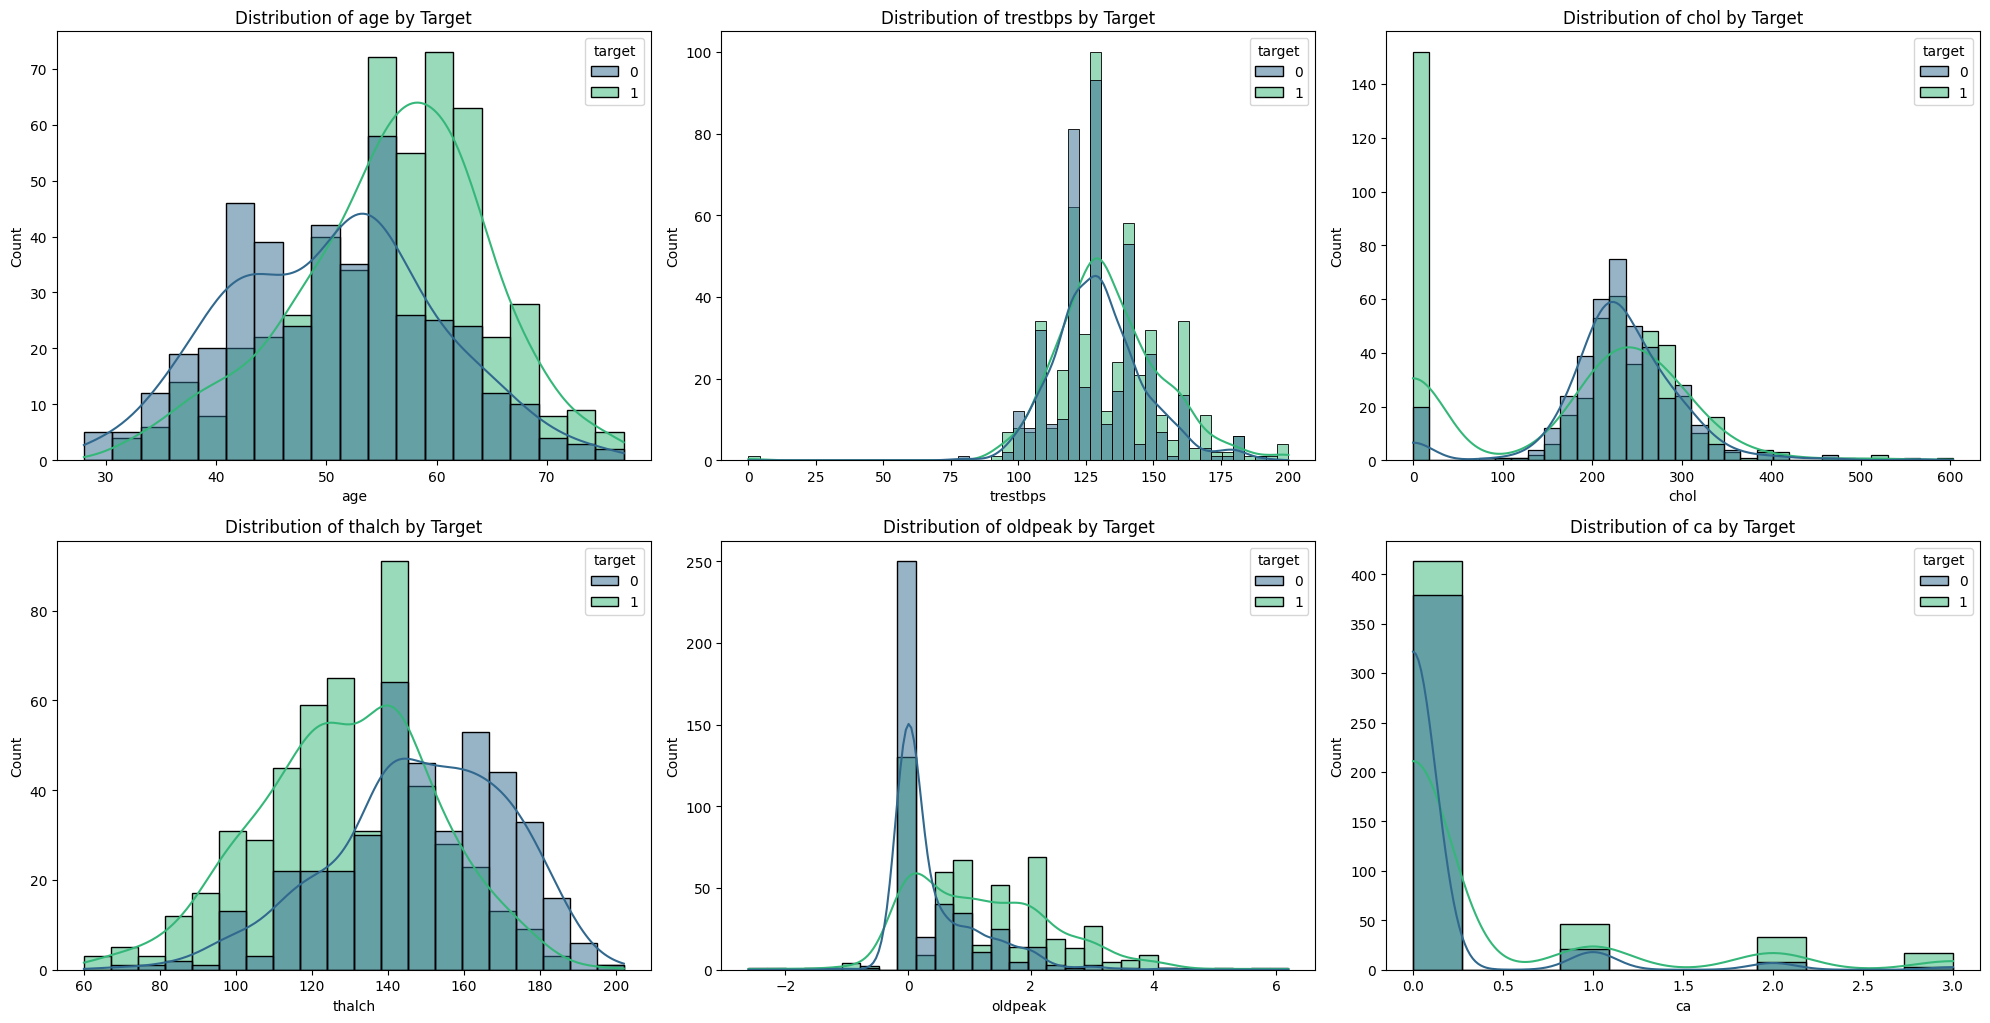


Visualizing correlation matrix:


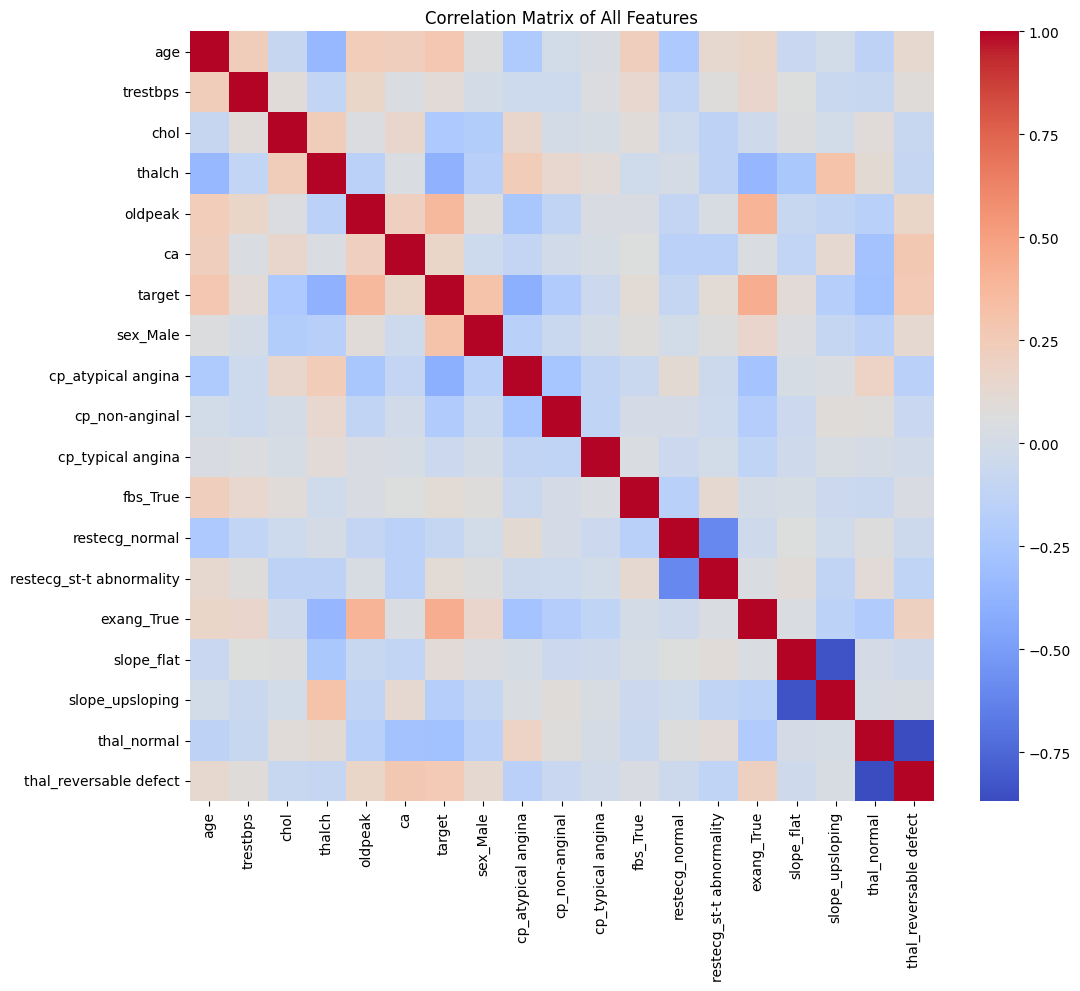

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
print("\nVisualizing distributions of numerical features against the target variable:")
numerical_features_final = df_encoded.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'target' in numerical_features_final:
    numerical_features_final.remove('target') # Exclude target for individual feature plots

plt.figure(figsize=(20, 15))
for i, col in enumerate(numerical_features_final):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid as needed
    sns.histplot(data=df_encoded, x=col, hue='target', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by Target')
plt.tight_layout()
plt.show()

print("\nVisualizing correlation matrix:")
plt.figure(figsize=(12, 10))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of All Features')
plt.show()

## Confusion Matrix:

X_train shape: (644, 18)
X_test shape: (276, 18)
y_train shape: (644,)
y_test shape: (276,)

Logistic Regression Model Evaluation:
Accuracy: 0.8261
Confusion Matrix:
[[ 99  24]
 [ 24 129]]
ROC AUC Score: 0.8892


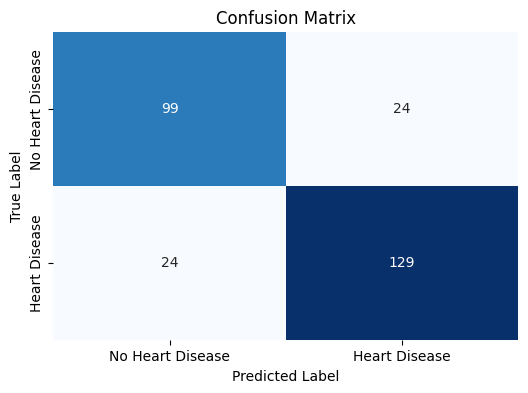

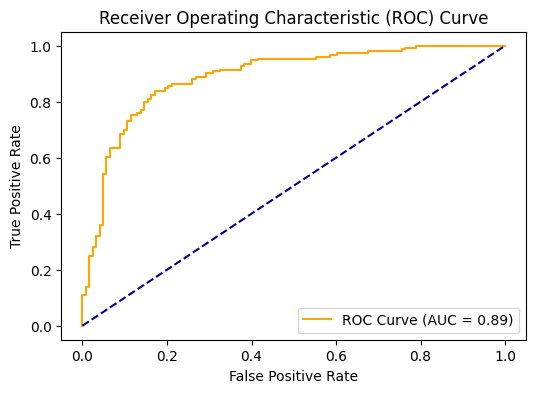


Feature Importance (Logistic Regression Coefficients):


,Feature,Coefficient,Absolute_Coefficient
7,cp_atypical angina,-1.683675,1.683675
8,cp_non-anginal,-1.128708,1.128708
6,sex_Male,1.057818,1.057818
13,exang_True,1.051829,1.051829
5,ca,0.799483,0.799483
14,slope_flat,0.711174,0.711174
9,cp_typical angina,-0.634657,0.634657
4,oldpeak,0.499245,0.499245
16,thal_normal,-0.415876,0.415876
10,fbs_True,0.396178,0.396178


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve
import numpy as np

# Prepare data for modeling
X = df_encoded.drop('target', axis=1)
y = df_encoded['target']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Train a Logistic Regression model
log_reg = LogisticRegression(solver='liblinear', random_state=42)
log_reg.fit(X_train, y_train)

# Make predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nLogistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Heart Disease', 'Heart Disease'],
            yticklabels=['No Heart Disease', 'Heart Disease'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='orange', label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

# Highlight important features (coefficients for Logistic Regression)
print("\nFeature Importance (Logistic Regression Coefficients):")
feature_importance = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
feature_importance['Absolute_Coefficient'] = np.abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)
display(feature_importance.head(10))

### Logistic Regression Model Evaluation Summary

The Logistic Regression model has been successfully trained and evaluated.

Here are the key results:

- **Training and Test Set Shapes:**
  - `X_train`: (644, 18)
  - `X_test`: (276, 18)
  - `y_train`: (644,)
  - `y_test`: (276,)

- **Model Evaluation:**
  - **Accuracy:** 0.8261
  - **Confusion Matrix:**
    ```
    [[ 99  24]
     [ 24 129]]
    ```
  - **ROC AUC Score:** 0.8892

- **Feature Importance (Top 10 Logistic Regression Coefficients):**
| Feature            | Coefficient | Absolute_Coefficient |
|:-------------------|:------------|:---------------------|
| cp_atypical angina | -1.683675   | 1.683675             |
| cp_non-anginal     | -1.128708   | 1.128708             |
| sex_Male           | 1.057818    | 1.057818             |
| exang_True         | 1.051829    | 1.051829             |
| ca                 | 0.799483    | 0.799483             |
| slope_flat         | 0.711174    | 0.711174             |
| cp_typical angina  | -0.634657   | 0.634657             |
| oldpeak            | 0.499245    | 0.499245             |
| thal_normal        | -0.415876   | 0.415876             |
| fbs_True           | 0.396178    | 0.396178             |

The confusion matrix and ROC curve plots were also displayed visually above.

#### **To improve the model accuracy beyond 82.6%, here are some strategies we can explore:**

1) Try More Sophisticated Models: While Logistic Regression is a good baseline, models like Decision Trees, Random Forests, Gradient Boosting (e.g., XGBoost, LightGBM), Support Vector Machines (SVMs), or even simple Neural Networks can often capture more complex relationships in the data.

2) Hyperparameter Tuning: For any chosen model, optimizing its hyperparameters can significantly boost performance. For Logistic Regression, we could tune parameters like C (regularization strength) or penalty.

3) Feature Engineering: Creating new features from existing ones (e.g., interaction terms, polynomial features) might provide more predictive power.

4) Advanced Imputation: While median/mode imputation is simple, more advanced techniques like K-Nearest Neighbors (KNN) imputation or Multiple Imputation by Chained Equations (MICE) could improve the quality of imputed data.

5) Addressing Class Imbalance (if any): If one class (heart disease vs. no heart disease) is significantly underrepresented, techniques like SMOTE (Synthetic Minority Over-sampling Technique) can help balance the dataset.